# DysphagiaGuard — IMU-Only Swallow Classifier (for Flutter)

This notebook trains a lightweight TinyML model using **IMU data only** (6-axis: `ax, ay, az, gx, gy, gz`), matching a phone-based or wearable-IMU-only deployment scenario.

It classifies each swallow event into:
- `0` = normal swallow
- `1` = delayed / incomplete swallow
- `2` = aspiration-risk event

**No real dataset exists yet**, so this notebook generates physiologically-inspired **synthetic IMU data** to build and validate the full pipeline. Swap in real recordings later — just match the CSV schema (see the data section).

**Output:** a `.tflite` model + a `feature_stats.json` (for normalization) you can drop straight into a Flutter app using the `tflite_flutter` package.

---
### Pipeline
1. Generate/load IMU data (3s windows @ 100Hz)
2. Extract time + frequency domain features per axis
3. Train a small dense NN
4. Convert to TFLite (float32, Flutter-ready) + int8 (optional, smaller)
5. Export everything needed for on-device inference in Flutter

## 0. Setup

In [ ]:
!pip install -q numpy pandas scikit-learn tensorflow

import numpy as np
import pandas as pd
import tensorflow as tf
import json, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

FS = 100                 # sampling rate (Hz) - match your IMU sensor config
WINDOW_SEC = 3.0          # seconds per swallow event window
N = int(FS * WINDOW_SEC)  # samples per window
CLASSES = ["normal", "delayed_incomplete", "aspiration_risk"]
IMU_CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]

OUT_DIR = "/content/dysphagia_imu_export"
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Data

### Option A — Synthetic data (default, runs out of the box)
Generates IMU-only signals mimicking laryngeal excursion patterns for each class.

### Option B — Real data
If you have real recordings, skip to the **"Load real data"** cell below and provide a CSV with columns:
`event_id, t, ax, ay, az, gx, gy, gz, label`
— one row per sample, `label` in `{normal, delayed_incomplete, aspiration_risk}`, ~3s windows at your sampling rate (update `FS` above to match).

In [ ]:
# ---- Option A: Synthetic IMU-only data generator ----

def _gaussian_bump(t, center, width, amp):
    return amp * np.exp(-0.5 * ((t - center) / width) ** 2)

def _make_normal(t, rng):
    center = 1.5 + rng.normal(0, 0.05)
    width = 0.18 + rng.normal(0, 0.02)
    lift = _gaussian_bump(t, center, width, amp=1.0)
    az = lift + rng.normal(0, 0.03, size=N)
    ax = 0.3 * lift + rng.normal(0, 0.03, size=N)
    ay = rng.normal(0, 0.02, size=N)
    gx = np.gradient(lift) * 20 + rng.normal(0, 0.05, size=N)
    gy = rng.normal(0, 0.03, size=N)
    gz = 0.4 * np.gradient(lift) * 20 + rng.normal(0, 0.03, size=N)
    return ax, ay, az, gx, gy, gz

def _make_delayed(t, rng):
    n_peaks = rng.integers(2, 4)
    lift = np.zeros(N)
    for _ in range(n_peaks):
        c = rng.uniform(0.8, 2.4)
        w = rng.uniform(0.25, 0.45)
        a = rng.uniform(0.35, 0.6)
        lift += _gaussian_bump(t, c, w, a)
    az = lift + rng.normal(0, 0.05, size=N)
    ax = 0.25 * lift + rng.normal(0, 0.05, size=N)
    ay = rng.normal(0, 0.03, size=N)
    gx = np.gradient(lift) * 12 + rng.normal(0, 0.06, size=N)
    gy = rng.normal(0, 0.04, size=N)
    gz = 0.3 * np.gradient(lift) * 12 + rng.normal(0, 0.04, size=N)
    return ax, ay, az, gx, gy, gz

def _make_aspiration(t, rng):
    base = 0.15 * rng.standard_normal(N)
    jitter = np.cumsum(rng.normal(0, 0.08, size=N))
    jitter -= jitter.mean()
    lift = 0.25 * np.sin(2 * np.pi * 0.7 * t + rng.uniform(0, 6)) + 0.3 * jitter + base
    az = lift + rng.normal(0, 0.08, size=N)
    ax = 0.2 * lift + rng.normal(0, 0.08, size=N)
    ay = 0.15 * lift + rng.normal(0, 0.06, size=N)
    gx = np.gradient(lift) * 25 + rng.normal(0, 0.1, size=N)
    gy = rng.normal(0, 0.08, size=N)
    gz = np.gradient(lift) * 15 + rng.normal(0, 0.08, size=N)
    return ax, ay, az, gx, gy, gz

GENERATORS = {"normal": _make_normal, "delayed_incomplete": _make_delayed, "aspiration_risk": _make_aspiration}

def generate_imu_dataset(n_per_class=250, seed=42):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, WINDOW_SEC, N, endpoint=False)
    rows, event_id = [], 0
    for label_idx, cls in enumerate(CLASSES):
        gen_fn = GENERATORS[cls]
        for _ in range(n_per_class):
            ax, ay, az, gx, gy, gz = gen_fn(t, rng)
            for i in range(N):
                rows.append({
                    "event_id": event_id, "t": t[i],
                    "ax": ax[i], "ay": ay[i], "az": az[i],
                    "gx": gx[i], "gy": gy[i], "gz": gz[i],
                    "label": cls, "label_idx": label_idx,
                })
            event_id += 1
    return pd.DataFrame(rows)

df = generate_imu_dataset(n_per_class=250)
print(df.shape)
df.head()

(225000, 10)


,event_id,t,ax,ay,az,gx,gy,gz,label,label_idx
0,0,0.00,0.025915,0.025489,0.022514,-0.007372,0.012607,0.039754,normal,0
1,0,0.01,-0.009856,-0.012552,0.028217,0.079414,-0.003072,0.009909,normal,0
2,0,0.02,-0.001840,-0.012732,-0.058531,-0.031110,-0.019517,-0.006352,normal,0
3,0,0.03,-0.031587,0.010823,-0.039065,0.103015,-0.020226,0.014962,normal,0
4,0,0.04,-0.010034,0.015259,0.003835,-0.011272,-0.021370,-0.063216,normal,0


In [ ]:
# ---- Option B: Load real data instead (uncomment and edit) ----

# from google.colab import files
# uploaded = files.upload()  # upload your CSV
# csv_name = list(uploaded.keys())[0]
# df = pd.read_csv(csv_name)
# label_map = {name: i for i, name in enumerate(CLASSES)}
# df["label_idx"] = df["label"].map(label_map)
# print(df.shape)
# df.head()

## 2. Quick visualization (sanity check)

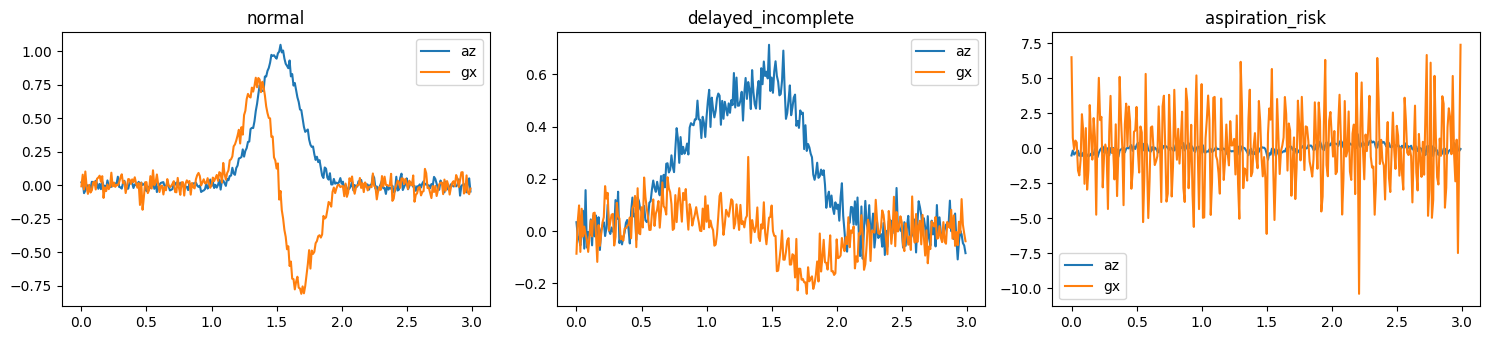

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax_i, cls in enumerate(CLASSES):
    eid = df[df["label"] == cls]["event_id"].iloc[0]
    g = df[df["event_id"] == eid]
    axes[ax_i].plot(g["t"], g["az"], label="az")
    axes[ax_i].plot(g["t"], g["gx"], label="gx")
    axes[ax_i].set_title(cls)
    axes[ax_i].legend()
plt.tight_layout()
plt.show()

## 3. Feature Extraction (IMU-only, 6 channels)

Per axis: mean, std, RMS, peak, signal energy, zero-crossing rate, spectral centroid, spectral flatness.
This mirrors what Edge Impulse's Spectral Analysis block would compute, but implemented directly so it's easy to reproduce identically in Dart for the Flutter app.

In [ ]:
def zero_crossing_rate(x):
    signs = np.sign(x - np.mean(x))
    signs[signs == 0] = 1
    return np.mean(signs[:-1] != signs[1:])

def signal_energy(x):
    return np.sum(x.astype(np.float64) ** 2) / len(x)

def spectral_centroid(x, fs=FS):
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    mag = np.abs(np.fft.rfft(x - np.mean(x)))
    if mag.sum() == 0:
        return 0.0
    return float(np.sum(freqs * mag) / np.sum(mag))

def spectral_flatness(x):
    mag = np.abs(np.fft.rfft(x - np.mean(x))) + 1e-12
    gmean = np.exp(np.mean(np.log(mag)))
    amean = np.mean(mag)
    return float(gmean / amean)

def extract_features_from_window(window_df):
    feats = {}
    for ch in IMU_CHANNELS:
        x = window_df[ch].values
        feats[f"{ch}_mean"] = np.mean(x)
        feats[f"{ch}_std"] = np.std(x)
        feats[f"{ch}_rms"] = np.sqrt(np.mean(x ** 2))
        feats[f"{ch}_peak"] = np.max(np.abs(x))
        feats[f"{ch}_energy"] = signal_energy(x)
        feats[f"{ch}_zcr"] = zero_crossing_rate(x)
        feats[f"{ch}_centroid"] = spectral_centroid(x)
        feats[f"{ch}_flatness"] = spectral_flatness(x)
    return feats

rows = []
for event_id, g in df.groupby("event_id"):
    feats = extract_features_from_window(g)
    feats["event_id"] = event_id
    feats["label"] = g["label"].iloc[0]
    feats["label_idx"] = g["label_idx"].iloc[0]
    rows.append(feats)

feat_df = pd.DataFrame(rows)
feature_cols = [c for c in feat_df.columns if c not in ("event_id", "label", "label_idx")]
print(feat_df.shape, "| features:", len(feature_cols))
feat_df.head()

(750, 51) | features: 48


,ax_mean,ax_std,ax_rms,ax_peak,ax_energy,ax_zcr,ax_centroid,ax_flatness,ay_mean,ay_std,...,gz_std,gz_rms,gz_peak,gz_energy,gz_zcr,gz_centroid,gz_flatness,event_id,label,label_idx
0,0.039542,0.089241,0.097609,0.362147,0.009528,0.180602,16.090689,0.528591,-0.001548,0.020242,...,0.113397,0.113476,0.349562,0.012877,0.347826,15.272799,0.472924,0,normal,0
1,0.044343,0.087748,0.098316,0.329839,0.009666,0.153846,16.860580,0.547127,0.000845,0.020259,...,0.110156,0.110162,0.331881,0.012136,0.341137,14.266610,0.459236,1,normal,0
2,0.048353,0.093382,0.105158,0.325927,0.011058,0.127090,15.967087,0.531505,0.000165,0.019859,...,0.103979,0.104014,0.301956,0.010819,0.294314,15.108385,0.492077,2,normal,0
3,0.048466,0.094472,0.106179,0.339070,0.011274,0.133779,17.566906,0.560602,0.000138,0.020819,...,0.105619,0.105659,0.332201,0.011164,0.317726,15.350506,0.454371,3,normal,0
4,0.043100,0.090147,0.099921,0.318027,0.009984,0.173913,17.169687,0.531635,0.000559,0.021010,...,0.105158,0.105161,0.318540,0.011059,0.347826,15.843760,0.521801,4,normal,0


## 4. Train / Test Split + Normalization

In [ ]:
X = feat_df[feature_cols].values.astype(np.float32)
y = feat_df["label_idx"].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "Test:", X_test_s.shape)

Train: (600, 48) Test: (150, 48)


## 5. Model Definition + Training

In [ ]:
def build_model(input_dim, n_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_model(input_dim=X_train_s.shape[1])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,147 (8.39 KB)

 Trainable params: 2,147 (8.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 - 3s - 92ms/step - accuracy: 0.5604 - loss: 0.8707 - val_accuracy: 0.8750 - val_loss: 0.5504
Epoch 2/100
30/30 - 0s - 16ms/step - accuracy: 0.9250 - loss: 0.4249 - val_accuracy: 1.0000 - val_loss: 0.2991
Epoch 3/100
30/30 - 1s - 20ms/step - accuracy: 0.9937 - loss: 0.2163 - val_accuracy: 1.0000 - val_loss: 0.1232
Epoch 4/100
30/30 - 1s - 27ms/step - accuracy: 0.9937 - loss: 0.0899 - val_accuracy: 1.0000 - val_loss: 0.0420
Epoch 5/100
30/30 - 0s - 15ms/step - accuracy: 1.0000 - loss: 0.0435 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 6/100
30/30 - 1s - 17ms/step - accuracy: 1.0000 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 7/100
30/30 - 0s - 11ms/step - accuracy: 1.0000 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 8/100
30/30 - 0s - 10ms/step - accuracy: 0.9979 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 9/100
30/30 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0031
E

In [ ]:
y_pred = np.argmax(model.predict(X_test_s), axis=1)
print("=== Classification Report (float model) ===")
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
=== Classification Report (float model) ===
                    precision    recall  f1-score   support

            normal       1.00      1.00      1.00        50
delayed_incomplete       1.00      1.00      1.00        50
   aspiration_risk       1.00      1.00      1.00        50

          accuracy                           1.00       150
         macro avg       1.00      1.00      1.00       150
      weighted avg       1.00      1.00      1.00       150

Confusion matrix:
 [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


## 6. Export for Flutter

Two things get exported:
1. **`.tflite` model** (float32 — simplest for `tflite_flutter`, no dequantization math needed in Dart). An optional int8 version is also produced if you want a smaller footprint.
2. **`feature_stats.json`** — the scaler mean/scale + feature order + class names, so the Flutter app can reproduce the *exact* same preprocessing before calling the model.

In [ ]:
# ---- Float32 TFLite export (recommended default for tflite_flutter) ----
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter.convert()

float_path = os.path.join(OUT_DIR, "dysphagia_imu_model_float32.tflite")
with open(float_path, "wb") as f:
    f.write(tflite_float_model)
print(f"Float32 model: {len(tflite_float_model)/1024:.1f} KB -> {float_path}")

Saved artifact at '/tmp/tmpzctru3fs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138808316257360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315867408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315859536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315863760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315867600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315863568: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 model: 10.4 KB -> /content/dysphagia_imu_export/dysphagia_imu_model_float32.tflite


In [ ]:
# ---- Optional: int8 quantized version (smaller, needs quant math in Dart) ----
def representative_dataset_gen():
    for i in range(min(200, len(X_train_s))):
        yield [X_train_s[i:i+1].astype(np.float32)]

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset_gen
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type = tf.int8
converter_q.inference_output_type = tf.int8
tflite_int8_model = converter_q.convert()

int8_path = os.path.join(OUT_DIR, "dysphagia_imu_model_int8.tflite")
with open(int8_path, "wb") as f:
    f.write(tflite_int8_model)
print(f"Int8 model: {len(tflite_int8_model)/1024:.1f} KB -> {int8_path}")

# Quick sanity check that quantized accuracy still holds
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()
in_d = interpreter.get_input_details()[0]
out_d = interpreter.get_output_details()[0]
in_scale, in_zero = in_d["quantization"]
out_scale, out_zero = out_d["quantization"]

preds = []
for i in range(len(X_test_s)):
    x_q = (X_test_s[i:i+1] / in_scale + in_zero).astype(np.int8)
    interpreter.set_tensor(in_d["index"], x_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(out_d["index"])
    out = (out_q.astype(np.float32) - out_zero) * out_scale
    preds.append(np.argmax(out))

print("\n=== Classification Report (INT8 quantized model) ===")
print(classification_report(y_test, preds, target_names=CLASSES))

Saved artifact at '/tmp/tmpe4wx0qw_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138808316257360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315867408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315859536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315863760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315867600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138808315863568: TensorSpec(shape=(), dtype=tf.resource, name=None)
Int8 model: 5.8 KB -> /content/dysphagia_imu_export/dysphagia_imu_model_int8.tflite

=== Classification Report (INT8 quantized model) ===
                    precision    recall  f1-score   support

            normal       1.00      1.00      1.00        50
delayed_incomplete       1.00      1.00      1

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ---- Export feature stats + metadata for Flutter-side preprocessing ----
export_meta = {
    "class_names": CLASSES,
    "imu_channels": IMU_CHANNELS,
    "sampling_rate_hz": FS,
    "window_seconds": WINDOW_SEC,
    "window_samples": N,
    "feature_order": feature_cols,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "input_shape": [1, len(feature_cols)],
    "notes": (
        "Flutter app must: (1) buffer 3s of 6-axis IMU samples at "
        "sampling_rate_hz, (2) compute the 8 features per channel in the "
        "EXACT order given in feature_order (mean, std, rms, peak, energy, "
        "zcr, centroid, flatness per axis in imu_channels order), "
        "(3) apply (x - scaler_mean) / scaler_scale elementwise, "
        "(4) feed as float32 input tensor to the .tflite model, "
        "(5) argmax the 3-class softmax output against class_names."
    ),
}

meta_path = os.path.join(OUT_DIR, "feature_stats.json")
with open(meta_path, "w") as f:
    json.dump(export_meta, f, indent=2)

print("Exported:", meta_path)
print(json.dumps({k: v for k, v in export_meta.items() if k not in ("scaler_mean", "scaler_scale")}, indent=2))

Exported: /content/dysphagia_imu_export/feature_stats.json
{
  "class_names": [
    "normal",
    "delayed_incomplete",
    "aspiration_risk"
  ],
  "imu_channels": [
    "ax",
    "ay",
    "az",
    "gx",
    "gy",
    "gz"
  ],
  "sampling_rate_hz": 100,
  "window_seconds": 3.0,
  "window_samples": 300,
  "feature_order": [
    "ax_mean",
    "ax_std",
    "ax_rms",
    "ax_peak",
    "ax_energy",
    "ax_zcr",
    "ax_centroid",
    "ax_flatness",
    "ay_mean",
    "ay_std",
    "ay_rms",
    "ay_peak",
    "ay_energy",
    "ay_zcr",
    "ay_centroid",
    "ay_flatness",
    "az_mean",
    "az_std",
    "az_rms",
    "az_peak",
    "az_energy",
    "az_zcr",
    "az_centroid",
    "az_flatness",
    "gx_mean",
    "gx_std",
    "gx_rms",
    "gx_peak",
    "gx_energy",
    "gx_zcr",
    "gx_centroid",
    "gx_flatness",
    "gy_mean",
    "gy_std",
    "gy_rms",
    "gy_peak",
    "gy_energy",
    "gy_zcr",
    "gy_centroid",
    "gy_flatness",
    "gz_mean",
    "gz_std",
    "gz

In [ ]:
# ---- Zip everything for download ----
import shutil
shutil.make_archive("/content/dysphagia_imu_export", "zip", OUT_DIR)

try:
    from google.colab import files
    files.download("/content/dysphagia_imu_export.zip")
except ImportError:
    print("Not running in Colab — find your files at /content/dysphagia_imu_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Using this in Flutter

1. Add to `pubspec.yaml`:
```yaml
dependencies:
  tflite_flutter: ^0.10.4
```
2. Put `dysphagia_imu_model_float32.tflite` and `feature_stats.json` in `assets/` and register them in `pubspec.yaml`.
3. In Dart:
   - Buffer incoming IMU samples (`ax..gz`) for `window_seconds` at `sampling_rate_hz`.
   - Compute the same 8 features per axis, in the exact order from `feature_stats.json['feature_order']`.
   - Normalize: `(value - scaler_mean[i]) / scaler_scale[i]` for each feature `i`.
   - Load the interpreter:
     ```dart
     final interpreter = await Interpreter.fromAsset('dysphagia_imu_model_float32.tflite');
     var input = [normalizedFeatures]; // shape [1, num_features]
     var output = List.filled(1 * 3, 0.0).reshape([1, 3]);
     interpreter.run(input, output);
     final predictedClass = output[0].indexOf(output[0].reduce(max));
     ```
   - Map `predictedClass` (0/1/2) to `feature_stats.json['class_names']`.

**Reminder:** this model is trained on synthetic data. Before shipping in the app, retrain this same notebook on real labeled IMU recordings (see Option B in Section 1) — the pipeline stays identical, only the input data changes.